In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.integrate import quad

plt.style.use('sty.mplstyle')

# Ottermann: Elastic Electron Scattering from $^{40}$ Ar

In [3]:
E1_Ottermann = 0.11575
E2_Ottermann = 0.24903
Theta1_Ottermann = np.array([55.017, 60.012, 65.008, 70.005, 75.021, 80.015, 85.020, 90.026, 95.040], dtype=np.float64)
Theta2_Ottermann = np.array([30.019, 35.010, 40.010, 45.009, 50.012, 55.017, 60.012], dtype=np.float64)
Exp_Xsection1_Ottermann = np.array([6302, 3417, 1867, 1027, 553.3, 295.1, 158.6, 82.81, 42.92], dtype=np.float64)*1e-5
Exp_Xsection2_Ottermann = np.array([9129, 2310, 536.7, 100.0, 13.68, 2.963, 3.041], dtype=np.float64)*1e-5

In [4]:
M_proton = 0.938272 # Proton mass in GeV
M_neutron = 0.939565 # Neutron mass in GeV

def Compute_Exp_FF(Energy, Theta, Xsection, A=40, Z=18):
    aEM = 1/137.036 # Electromagnetic Coupling
    M = Z*M_proton + (A-Z)*M_neutron # Target mass in GeV
    E0 = Energy
    Q = np.ones_like(Theta)
    FF = np.ones_like(Theta)
    for i in range(len(Theta)):
        t = np.pi*Theta[i]/360
        E = E0/( 1 + 2*E0*np.sin(t)**2/M ) # Energy in GeV
        Q2 = 4*E0*E*np.sin(t)**2 # Momentum transfer squared
        Q[i] = np.sqrt(Q2) # Momentum transfer in GeV
        X_section_Mott = aEM**2 * np.cos(t)**2 / ( 4*E0**2*np.sin(t)**4 ) / (1 + 2*E0*np.sin(t)**2/M)
        X_section_Mott *= Z**2 # Mott Cross Section in GeV^-2
        X_section_Mott *= ( 0.1973**2 ) # fm^2
        FF_squared = Xsection[i]/X_section_Mott
        FF[i] = np.sqrt(FF_squared)
    return Q, FF

# Fourier-Bessel Expansion

In [5]:
R_FBSE = 9/0.1973 # GeV^{-1}
a_FBSE = np.array([0.30451e-1, 0.55337e-1, 0.20203e-1, -0.16765e-1, -0.13578e-1,
                   -0.43204e-4, 0.91988e-3, -0.41205e-3, 0.11971e-3, -0.19801e-4,
                   -0.43204e-5, 0.61205e-5, -0.37803e-5, 0.18001e-5, -0.77407e-6], dtype=np.float64)

norm_FBSE = 0
for i in range(len(a_FBSE)):
    n = i + 1
    norm_FBSE -=  a_FBSE[i]*(-1)**n/n**2

def FBSE_FF(Q2):
    Q = np.sqrt(Q2)
    aux = np.ones_like(Q2)
    cond = Q!=0
    s = np.zeros_like(Q[cond])
    for i in range(len(a_FBSE)):
        n = i + 1
        s += ( a_FBSE[i]*(-1)**n/(Q[cond]*R_FBSE + n*np.pi) )*( np.sin(Q[cond]*R_FBSE)/(Q[cond]*R_FBSE - n*np.pi) )
    s = s*np.pi**2/(Q[cond]*R_FBSE)
    aux[cond] = s/norm_FBSE
    return aux

# Three-parameter Fermi Model

In [6]:
c_Fermi = 3.73/0.1973 # GeV^{-1}
z_Fermi = 0.62/0.1973 # GeV^{-1}
w_Fermi = -0.19
R_Fermi = (3.48/0.1973)*5 # GeV^{-1}

def rho_Fermi(r):
    num = 1 + w_Fermi*r**2/c_Fermi**2
    denom = 1 + np.exp( (r-c_Fermi)/z_Fermi )
    return num/denom

def rho_Fermi_aux(r, Q2):
    Q = np.sqrt(Q2)
    if Q == 0:
        return r**2 * rho_Fermi(r)
    else:
        return r**2 * np.sin(Q*r)/(Q*r) * rho_Fermi(r)

norm_Fermi, _ = quad(rho_Fermi_aux, 0, R_Fermi, args=(0,))

def Fermi_FF(Q2):
    if Q2 == 0:
        main = norm_Fermi
    else:
        main, _ = quad(rho_Fermi_aux, 0, R_Fermi, args=(Q2,))
    return main/norm_Fermi

Fermi_FF = np.vectorize(Fermi_FF)

# Helm Form Factor

In [7]:
A = 40
r0_Helm = 0.52 # fm
s_Helm = 0.9 # fm
R0_Helm = (1.23*A**(1/3) - 0.6)**2 + 7*np.pi**2*r0_Helm**2/3 - 5*s_Helm**2
R0_Helm = np.sqrt(R0_Helm) # fm
R0_Helm = R0_Helm/0.1973 # GeV^{-1}
s_Helm = s_Helm/0.1973 # GeV^{-1}

def j1_aux(x):
    main = 1/3*np.ones_like(x)
    cond = x != 0
    num = np.sin(x[cond]) - x[cond]*np.cos(x[cond])
    denom = x[cond]**3
    main[cond] = num/denom
    return main

def Helm_FF(Q2):
    Q = np.sqrt(Q2)
    return 3*j1_aux(Q*R0_Helm)*np.exp(-Q2*s_Helm**2/2)

# Klein-Nystrand Form Factor

In [8]:
RA_KN = 1.23*A**(1/3) # fm
RA_KN = RA_KN/0.1973 # GeV^{-1}

r0_adKN = 3.427 # fm
ak_adKN = 0.7 # fm
RA_adKN = 5*r0_adKN**2/3 - 10*ak_adKN**2 #fm^2
RA_adKN = np.sqrt(RA_adKN) # fm
RA_adKN = RA_adKN/0.1973 # GeV⁻{-1}

def KN_FF(Q2, R=1):
    Q = np.sqrt(Q2)
    ak_aux = 0.7/0.1973 # GeV^{-1}
    return 3*j1_aux(Q*R)/( 1 + Q2*ak_aux**2 )

# Additional Nuclear Theory Form Factors

## HF-SKE2

In [9]:
HF_SKE2_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_HF-SKE2.dat', usecols=1) # fm^{-1}
HF_SKE2_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_HF-SKE2.dat', usecols=14)
q_HFSKE2 = HF_SKE2_xaxis*0.1973 # GeV
abs_HFSKE2 = np.abs( HF_SKE2_yaxis )

## N2LO

In [10]:
N2LO_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_N2LO.dat', usecols=0) # fm^{-1}
N2LO_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_N2LO.dat', usecols=1)
q_N2LO = N2LO_xaxis*0.1973 # GeV
abs_N2LO = np.abs( N2LO_yaxis )

## RMF

In [11]:
RMF_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_RMF.dat.txt', usecols=0) # fm^{-1}
RMF_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_RMF.dat.txt', usecols=1)
q_RMF = RMF_xaxis*0.1973 # GeV
abs_RMF = np.abs( RMF_yaxis )

## Shell Model (VERIFICAR)

In [12]:
q_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=0) # fm^{-1}
q_ShellModel = q_ShellModel*0.1973 # GeV
Fp_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=1)
Fn_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=2)

Z_aux = 18
A_aux = 40
N_aux = A_aux - Z_aux
sin2Thetaw = 0.23119
QW = (1 - 4*sin2Thetaw)*Z_aux - N_aux
Fw_ShellModel = ( (1-4*sin2Thetaw)*Z_aux*Fp_ShellModel**2 - N_aux*Fn_ShellModel**2 )/QW
abs_Fw_ShellModel = np.abs( Fw_ShellModel )

In [13]:
Qmax = 0.7 # GeV
Qvals = np.linspace(0, Qmax, 500)

In [14]:
abvals_Fermi_FF = np.abs( Fermi_FF(Qvals**2) )
abvals_Helm_FF = np.abs( Helm_FF(Qvals**2) )
abvals_KN_FF = np.abs( KN_FF(Qvals**2, R=RA_KN) )
abvals_adKN_FF = np.abs( KN_FF(Qvals**2, R=RA_adKN) )
abvals_FBSE_FF = np.abs( FBSE_FF(Qvals**2) )

In [15]:
Q1_Ottermann, FF1_Ottermann = Compute_Exp_FF(E1_Ottermann, Theta1_Ottermann, Exp_Xsection1_Ottermann)
Q2_Ottermann, FF2_Ottermann = Compute_Exp_FF(E2_Ottermann, Theta2_Ottermann, Exp_Xsection2_Ottermann)
Q_Ottermann = np.concatenate( (Q1_Ottermann, Q2_Ottermann) )
FF_Ottermann = np.concatenate( (FF1_Ottermann, FF2_Ottermann) )

# Plotting all the Form Factors

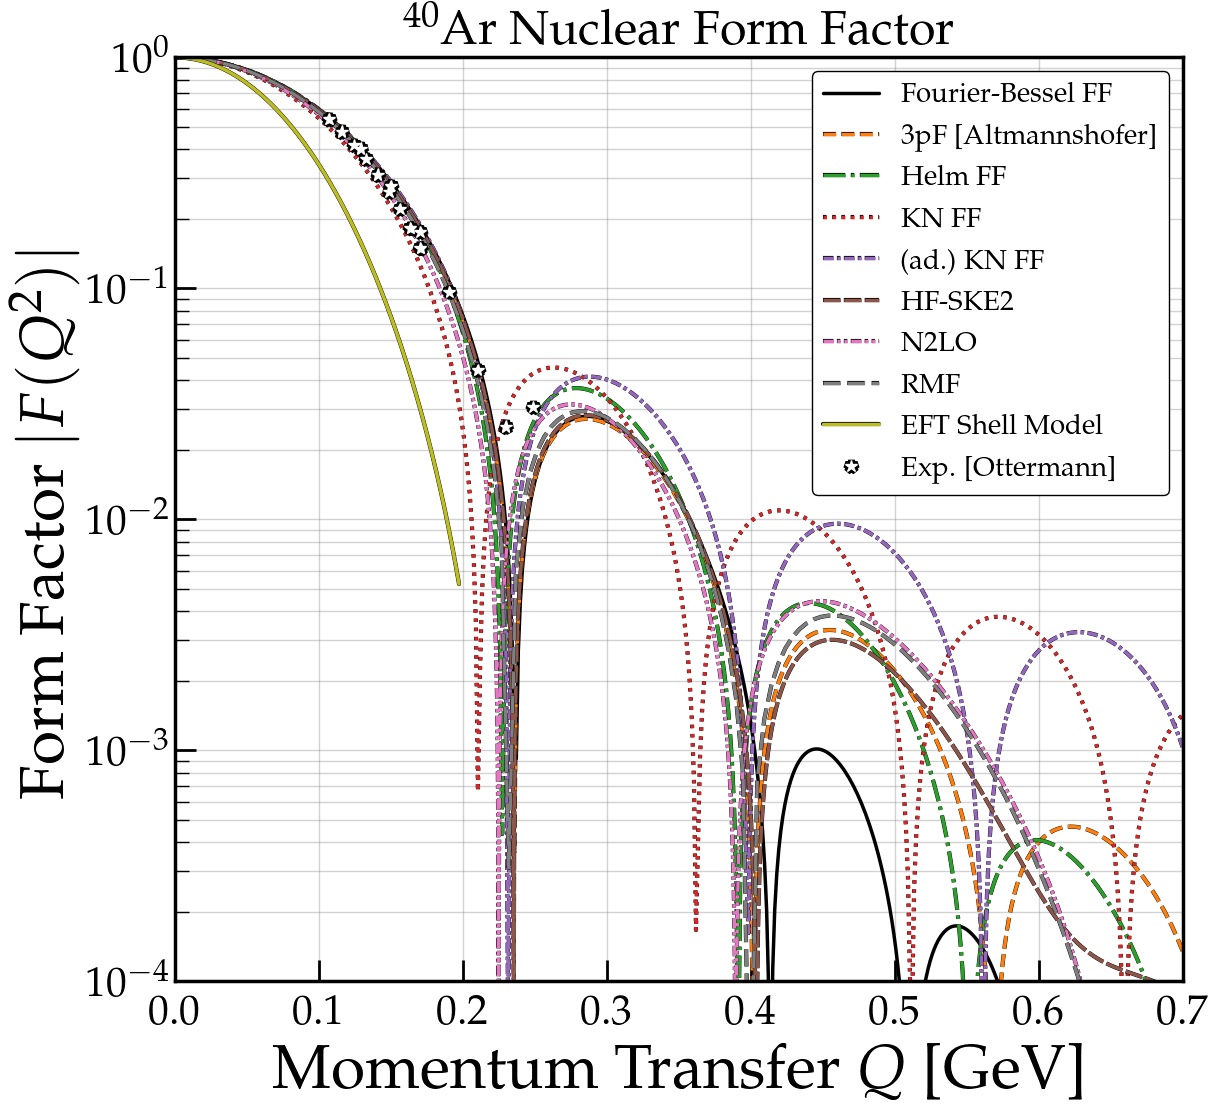

In [16]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Qvals, abvals_FBSE_FF, color='black', ls="-", lw=2.5, label='Fourier-Bessel FF')
ax.plot(Qvals, abvals_Fermi_FF, color='#ff7f0e', ls="--", lw=2.5, label='3pF [Altmannshofer]', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abvals_Helm_FF, color='#2ca02c', ls="-.", lw=2.5, label='Helm FF', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abvals_KN_FF, color='#d62728', ls=":", lw=2.5, label='KN FF', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abvals_adKN_FF, color='#9467bd', ls=(0, (3, 1, 1, 1)), lw=2.5, label='(ad.) KN FF', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_HFSKE2, abs_HFSKE2, color='#8c564b', ls=(0, (5, 1)), lw=2.5, label='HF-SKE2', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_N2LO, abs_N2LO, color='#e377c2', ls=(0, (3, 1, 1, 1, 1, 1)), lw=2.5, label='N2LO', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_RMF, abs_RMF, color='#7f7f7f', ls=(0, (5, 2, 5, 2)), lw=2.5, label='RMF', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_ShellModel, abs_Fw_ShellModel, color='#bcbd22', ls='-', lw=2.5, label='EFT Shell Model', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Q_Ottermann, FF_Ottermann, ls='', marker='*', markersize=9, color='white', path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()], zorder=10, label='Exp. [Ottermann]')

ax.xaxis.grid(True, ls= '-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls= '-', which='both', color='gray', alpha=0.35)
ax.legend(fontsize=20, loc='upper right', frameon=True, framealpha=1, edgecolor='k', fancybox=True)
ax.tick_params(which='both', right=False, top=False)
ax.set_xlabel(r'Momentum Transfer $Q$ [GeV]')
ax.set_ylabel(r'Form Factor $|F(Q^2)|$')
ax.set_title(r'$^{40}$Ar Nuclear Form Factor')

ax.set_yscale('log')
ax.set_ylim([1e-4, 1])
ax.set_xlim([0, Qmax])

plt.savefig('../Plots/Figures_PDF/40ArgonFF.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/40ArgonFF.png', transparent=False, bbox_inches='tight')